## 1. Data Loading and Exploration:

In [153]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv', encoding='latin-1')

In [154]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [155]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [156]:
df.describe()      # summary statistics for numeric columns

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [157]:
X = df.drop(columns=['price_range'])
y = df['price_range']

binary_cols = [col for col in X.columns if X[col].nunique() == 2]
non_binary_cols = [col for col in X.columns if col not in binary_cols]

print(f"Binary columns ({len(binary_cols)}): {binary_cols}")
print(f"Non-binary columns ({len(non_binary_cols)}): {non_binary_cols}")

Binary columns (6): ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']
Non-binary columns (14): ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']


In [158]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


In [159]:
print("Mean:\n", df.mean())

Mean:
 battery_power    1238.51850
blue                0.49500
clock_speed         1.52225
dual_sim            0.50950
fc                  4.30950
four_g              0.52150
int_memory         32.04650
m_dep               0.50175
mobile_wt         140.24900
n_cores             4.52050
pc                  9.91650
px_height         645.10800
px_width         1251.51550
ram              2124.21300
sc_h               12.30650
sc_w                5.76700
talk_time          11.01100
three_g             0.76150
touch_screen        0.50300
wifi                0.50700
price_range         1.50000
dtype: float64


In [160]:
print("\nMedian:\n", df.median())


Median:
 battery_power    1226.0
blue                0.0
clock_speed         1.5
dual_sim            1.0
fc                  3.0
four_g              1.0
int_memory         32.0
m_dep               0.5
mobile_wt         141.0
n_cores             4.0
pc                 10.0
px_height         564.0
px_width         1247.0
ram              2146.5
sc_h               12.0
sc_w                5.0
talk_time          11.0
three_g             1.0
touch_screen        1.0
wifi                1.0
price_range         1.5
dtype: float64


In [161]:
print("\nStd Dev:\n", df.std())


Std Dev:
 battery_power     439.418206
blue                0.500100
clock_speed         0.816004
dual_sim            0.500035
fc                  4.341444
four_g              0.499662
int_memory         18.145715
m_dep               0.288416
mobile_wt          35.399655
n_cores             2.287837
pc                  6.064315
px_height         443.780811
px_width          432.199447
ram              1084.732044
sc_h                4.213245
sc_w                4.356398
talk_time           5.463955
three_g             0.426273
touch_screen        0.500116
wifi                0.500076
price_range         1.118314
dtype: float64


In [162]:
print("\nMin:\n", df.min())


Min:
 battery_power    501.0
blue               0.0
clock_speed        0.5
dual_sim           0.0
fc                 0.0
four_g             0.0
int_memory         2.0
m_dep              0.1
mobile_wt         80.0
n_cores            1.0
pc                 0.0
px_height          0.0
px_width         500.0
ram              256.0
sc_h               5.0
sc_w               0.0
talk_time          2.0
three_g            0.0
touch_screen       0.0
wifi               0.0
price_range        0.0
dtype: float64


In [163]:
print("\nMax:\n", df.max())


Max:
 battery_power    1998.0
blue                1.0
clock_speed         3.0
dual_sim            1.0
fc                 19.0
four_g              1.0
int_memory         64.0
m_dep               1.0
mobile_wt         200.0
n_cores             8.0
pc                 20.0
px_height        1960.0
px_width         1998.0
ram              3998.0
sc_h               19.0
sc_w               18.0
talk_time          20.0
three_g             1.0
touch_screen        1.0
wifi                1.0
price_range         3.0
dtype: float64


In [164]:
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


In [165]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [166]:
print("\nTarget value counts:\n", df['price_range'].value_counts())


Target value counts:
 price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


## 2. Data Cleaning and Preprocessing:

In [167]:
print("\nTotal missing values:", df.isnull().sum().sum())


Total missing values: 0


In [168]:
print("Categorical columns:", df.select_dtypes(include=['object', 'category']).columns.to_list())

Categorical columns: []


## 3. Statistical Analysis with NumPy and SciPy:

In [169]:
for col in df.columns.to_list():
    values = df[col].to_numpy()

    mean_val = np.mean(values)
    median_val = np.median(values)
    mode_val = stats.mode(values, keepdims=True).mode[0]

    range_val = np.ptp(values)
    variance_val = np.var(values, ddof=1)
    std_val = np.std(values, ddof=1)

    skewness = stats.skew(values)
    kurt = stats.kurtosis(values)
    
    print(f"{col}")
    print(f"    mean = {mean_val:.2f}")
    print(f"    median = {median_val:.2f}")
    print(f"    mode = {mode_val:.2f}")
    print(f"    range = {range_val:.2f}")
    print(f"    variance = {variance_val:.2f}")
    print(f"    deviation = {std_val:.2f}")
    print(f"    skewness = {skewness:.2f}")
    print(f"    kurtosis = {kurt:.2f}")


battery_power
    mean = 1238.52
    median = 1226.00
    mode = 618.00
    range = 1497.00
    variance = 193088.36
    deviation = 439.42
    skewness = 0.03
    kurtosis = -1.22
blue
    mean = 0.49
    median = 0.00
    mode = 0.00
    range = 1.00
    variance = 0.25
    deviation = 0.50
    skewness = 0.02
    kurtosis = -2.00
clock_speed
    mean = 1.52
    median = 1.50
    mode = 0.50
    range = 2.50
    variance = 0.67
    deviation = 0.82
    skewness = 0.18
    kurtosis = -1.32
dual_sim
    mean = 0.51
    median = 1.00
    mode = 1.00
    range = 1.00
    variance = 0.25
    deviation = 0.50
    skewness = -0.04
    kurtosis = -2.00
fc
    mean = 4.31
    median = 3.00
    mode = 0.00
    range = 19.00
    variance = 18.85
    deviation = 4.34
    skewness = 1.02
    kurtosis = 0.27
four_g
    mean = 0.52
    median = 1.00
    mode = 1.00
    range = 1.00
    variance = 0.25
    deviation = 0.50
    skewness = -0.09
    kurtosis = -1.99
int_memory
    mean = 32.05
    med

In [170]:
groups = df['price_range'].unique()

for col in df.columns.to_list():
    if col == 'price_range':
        continue

    samples = [df[df['price_range'] == g][col].to_numpy() for g in groups]
    f_stat, p_value = stats.f_oneway(*samples)
    significance = "significant" if p_value < 0.05 else "not significant"

    print(f"{col}")
    print(f"    F-statistic = {f_stat:.2f}")
    print(f"    p-value = {p_value:.2f}")
    print(f"    result = {significance}")

battery_power
    F-statistic = 31.60
    p-value = 0.00
    result = significant
blue
    F-statistic = 0.48
    p-value = 0.70
    result = not significant
clock_speed
    F-statistic = 0.49
    p-value = 0.69
    result = not significant
dual_sim
    F-statistic = 0.43
    p-value = 0.73
    result = not significant
fc
    F-statistic = 0.77
    p-value = 0.51
    result = not significant
four_g
    F-statistic = 1.06
    p-value = 0.37
    result = not significant
int_memory
    F-statistic = 2.92
    p-value = 0.03
    result = significant
m_dep
    F-statistic = 1.50
    p-value = 0.21
    result = not significant


mobile_wt
    F-statistic = 3.59
    p-value = 0.01
    result = significant
n_cores
    F-statistic = 2.63
    p-value = 0.05
    result = significant
pc
    F-statistic = 0.83
    p-value = 0.48
    result = not significant
px_height
    F-statistic = 19.48
    p-value = 0.00
    result = significant
px_width
    F-statistic = 22.62
    p-value = 0.00
    result = significant
ram
    F-statistic = 3520.11
    p-value = 0.00
    result = significant
sc_h
    F-statistic = 2.23
    p-value = 0.08
    result = not significant
sc_w
    F-statistic = 1.67
    p-value = 0.17
    result = not significant
talk_time
    F-statistic = 1.63
    p-value = 0.18
    result = not significant
three_g
    F-statistic = 0.46
    p-value = 0.71
    result = not significant
touch_screen
    F-statistic = 1.29
    p-value = 0.28
    result = not significant
wifi
    F-statistic = 0.28
    p-value = 0.84
    result = not significant


In [171]:
target = df['price_range'].to_numpy()

strength_levels = {
    0.1: "negligible",
    0.3: "weak",
    0.5: "moderate",
    1.0: "strong"
}

def get_strength(abs_r):
    for threshold, label in strength_levels.items():
        if abs_r < threshold:
            return label
    return "strong"

for col in df.columns.to_list():
    if col == 'price_range':
        continue

    values = df[col].to_numpy()

    pearson_corr, pearson_p = stats.pearsonr(values, target)
    spearman_corr, spearman_p = stats.spearmanr(values, target)

    strength = get_strength(abs(spearman_corr))
    direction = "positive" if spearman_corr > 0 else "negative"
    # significance = "significant" if spearman_p < 0.05 else "not significant"

    print(f"{col}")
    print(f"    pearson r = {pearson_corr:.4f} (p = {pearson_p:.4f})")
    print(f"    spearman r = {spearman_corr:.4f} (p = {spearman_p:.4f})")
    print(f"    conclusion = {strength} {direction} correlation")

battery_power
    pearson r = 0.2007 (p = 0.0000)
    spearman r = 0.2000 (p = 0.0000)
    conclusion = weak positive correlation
blue
    pearson r = 0.0206 (p = 0.3578)
    spearman r = 0.0206 (p = 0.3578)
    conclusion = negligible positive correlation
clock_speed
    pearson r = -0.0066 (p = 0.7678)
    spearman r = -0.0054 (p = 0.8080)
    conclusion = negligible negative correlation
dual_sim
    pearson r = 0.0174 (p = 0.4356)
    spearman r = 0.0174 (p = 0.4356)
    conclusion = negligible positive correlation
fc
    pearson r = 0.0220 (p = 0.3255)
    spearman r = 0.0242 (p = 0.2800)
    conclusion = negligible positive correlation
four_g
    pearson r = 0.0148 (p = 0.5091)
    spearman r = 0.0148 (p = 0.5091)
    conclusion = negligible positive correlation


int_memory
    pearson r = 0.0444 (p = 0.0469)
    spearman r = 0.0443 (p = 0.0477)
    conclusion = negligible positive correlation
m_dep
    pearson r = 0.0009 (p = 0.9696)
    spearman r = -0.0003 (p = 0.9885)
    conclusion = negligible negative correlation
mobile_wt
    pearson r = -0.0303 (p = 0.1755)
    spearman r = -0.0302 (p = 0.1768)
    conclusion = negligible negative correlation
n_cores
    pearson r = 0.0044 (p = 0.8441)
    spearman r = 0.0047 (p = 0.8353)
    conclusion = negligible positive correlation
pc
    pearson r = 0.0336 (p = 0.1331)
    spearman r = 0.0328 (p = 0.1423)
    conclusion = negligible positive correlation
px_height
    pearson r = 0.1489 (p = 0.0000)
    spearman r = 0.1319 (p = 0.0000)
    conclusion = weak positive correlation
px_width
    pearson r = 0.1658 (p = 0.0000)
    spearman r = 0.1651 (p = 0.0000)
    conclusion = weak positive correlation
ram
    pearson r = 0.9170 (p = 0.0000)
    spearman r = 0.9171 (p = 0.0000)
    conclusion = stro

## 4. Data Visualization with Matplotlib:

We can ignore binaries datas

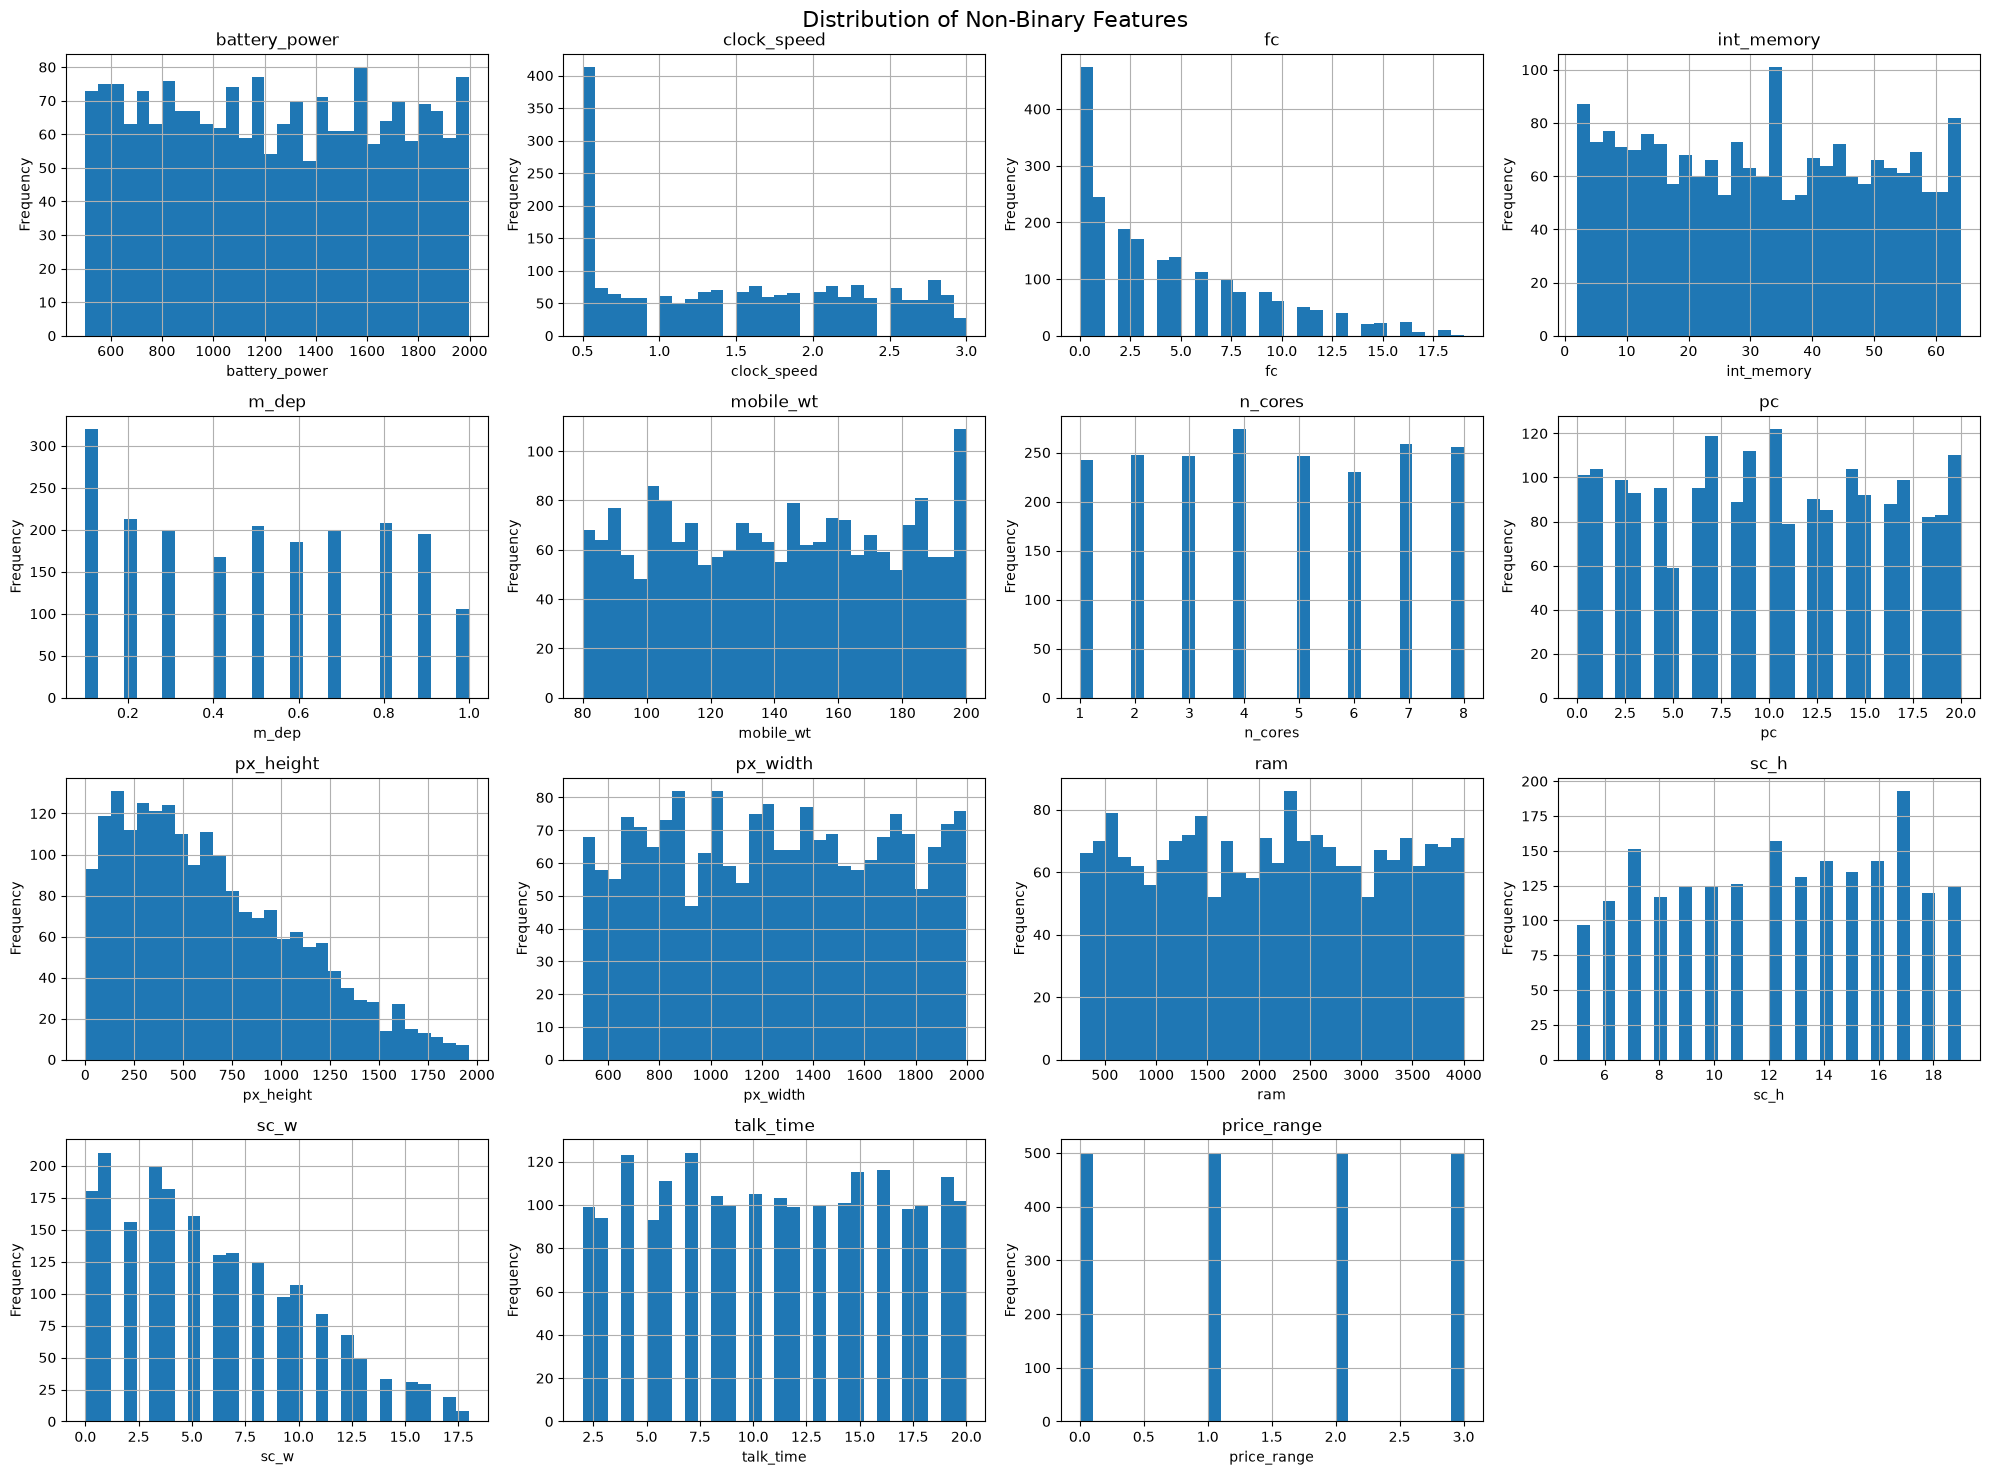

In [172]:
df_datas = df.drop(columns=['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi'])

axes = df_datas.hist(figsize=(20, 15), bins=30)
for ax, col in zip(axes.flatten(), df_datas.columns):
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.suptitle("Distribution of Non-Binary Features", fontsize=16)
plt.tight_layout()
plt.show()

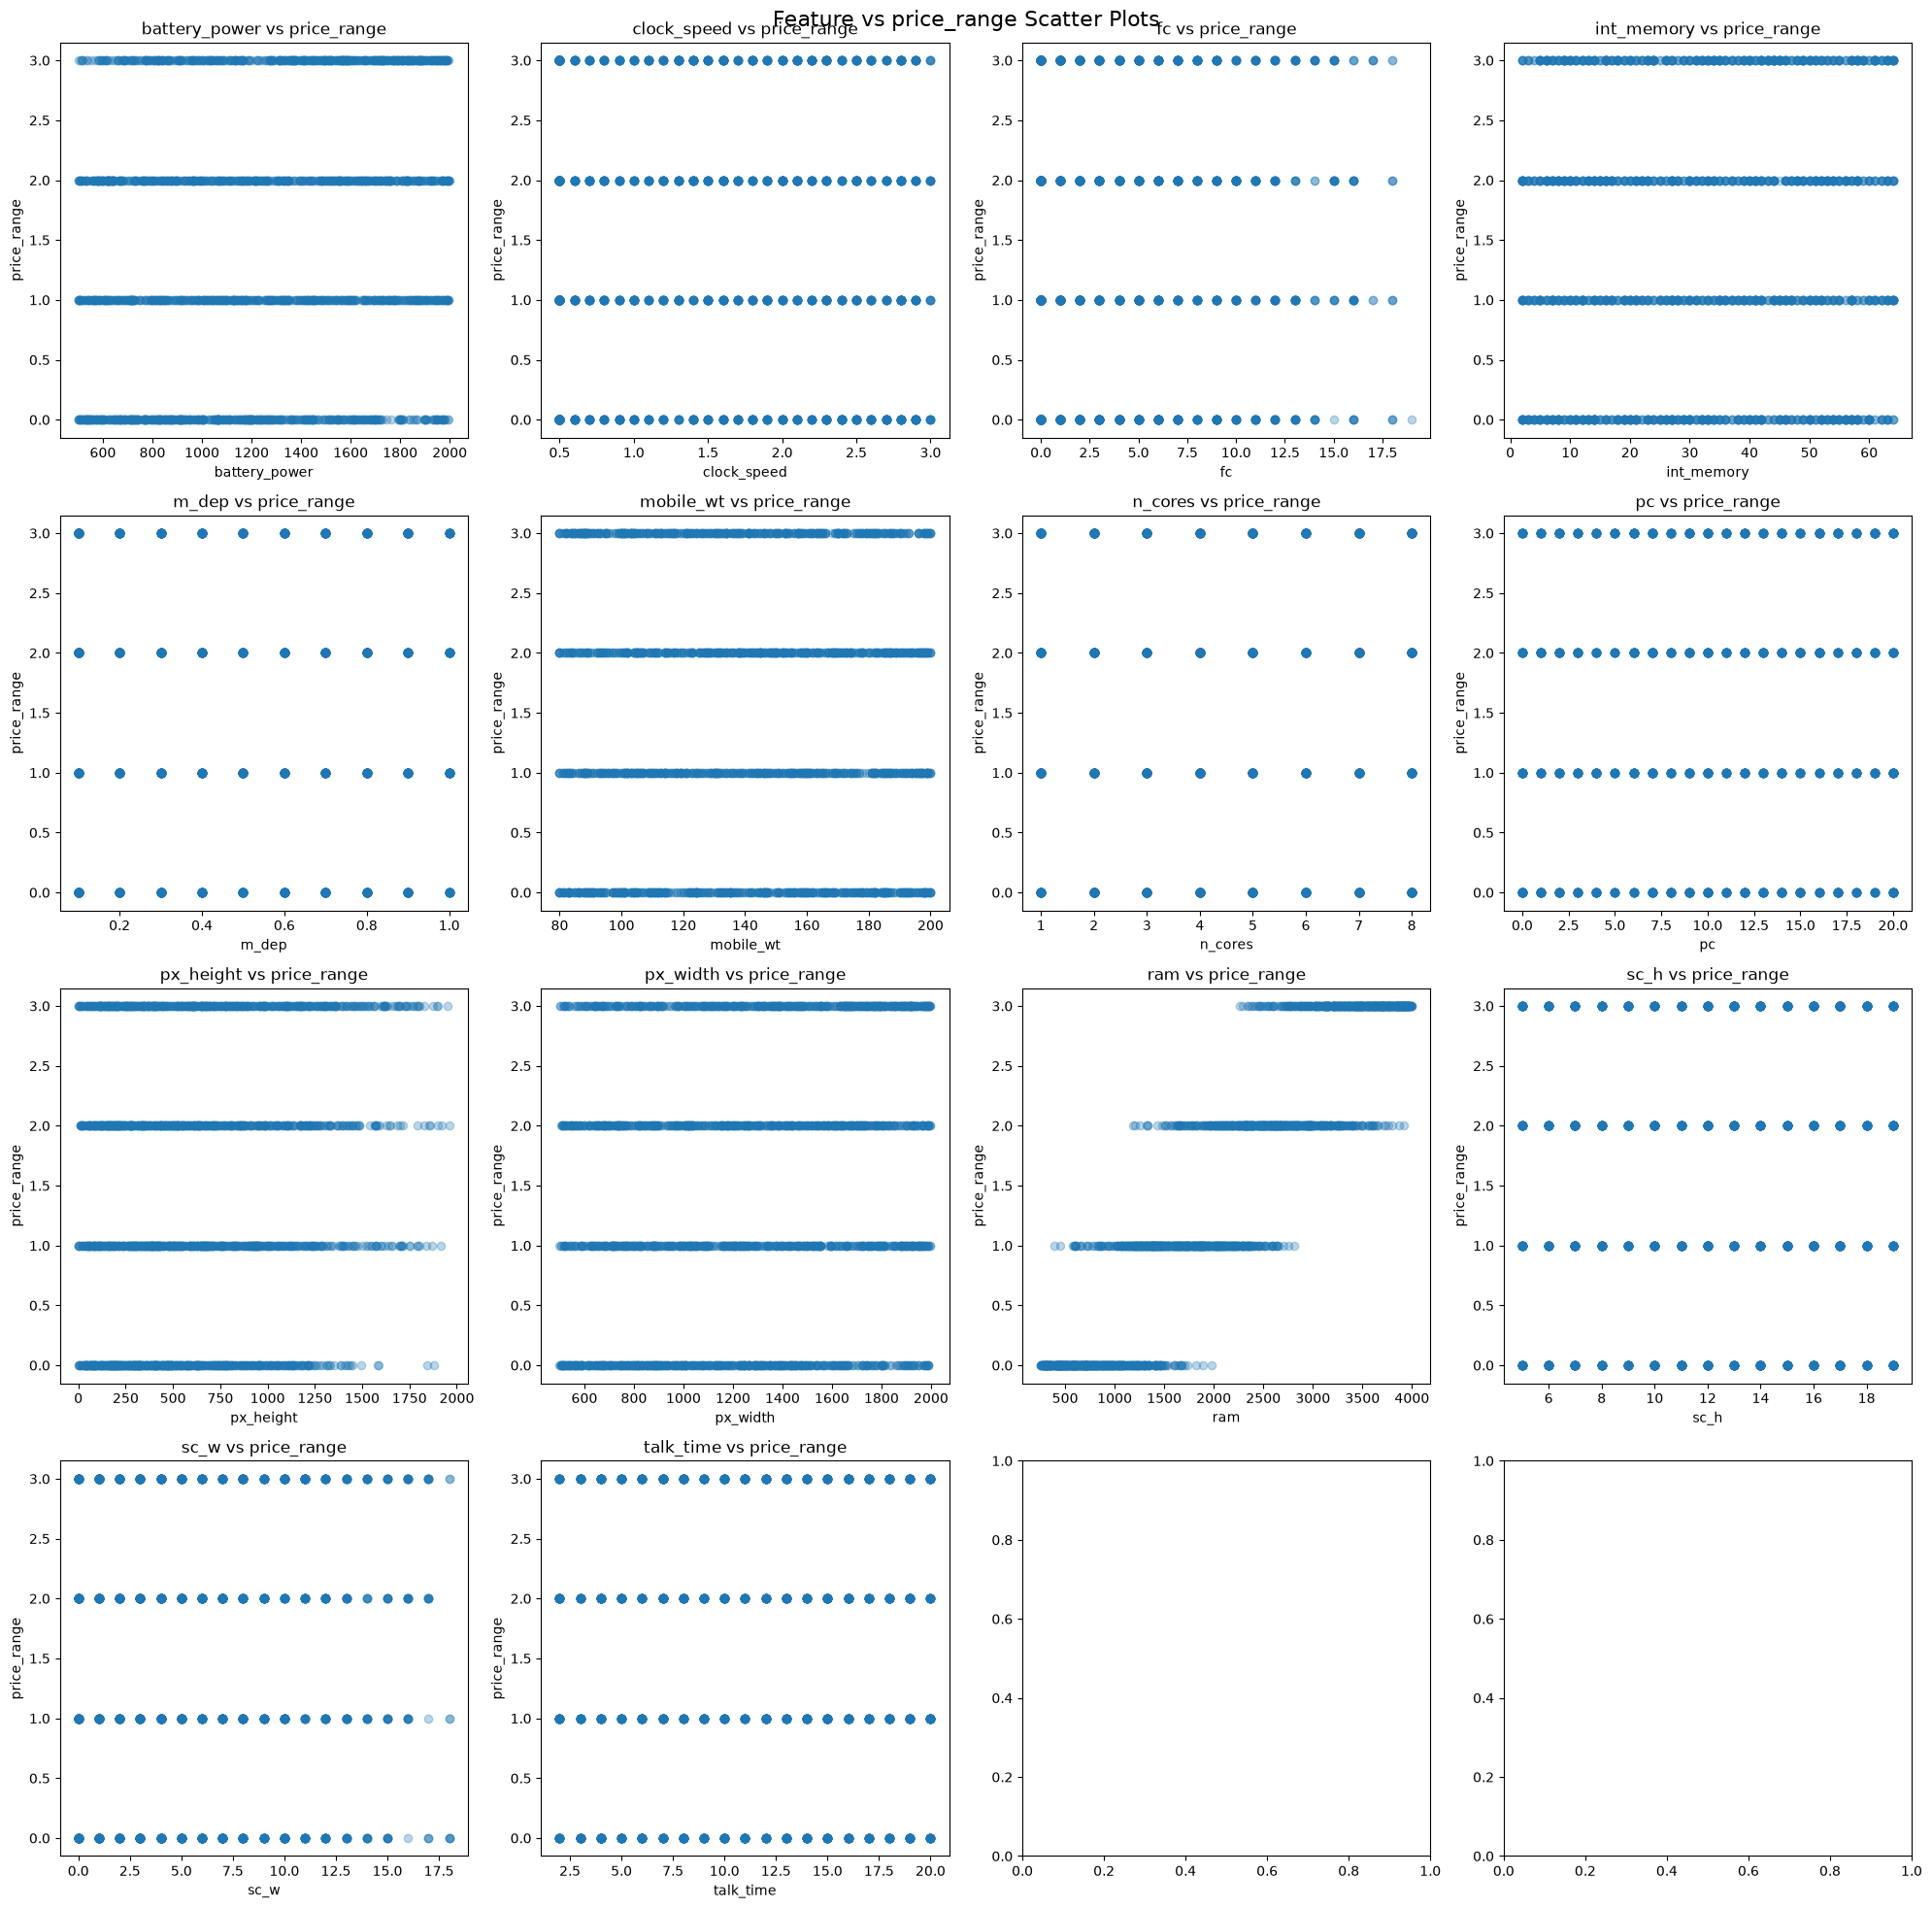

In [173]:
features = df_datas.drop(columns=['price_range']).columns.to_list()

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df_datas[col], df_datas['price_range'], alpha=0.3)
    axes[i].set_title(f"{col} vs price_range")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('price_range')

plt.suptitle("Feature vs price_range Scatter Plots", fontsize=16)
plt.tight_layout()
plt.show()

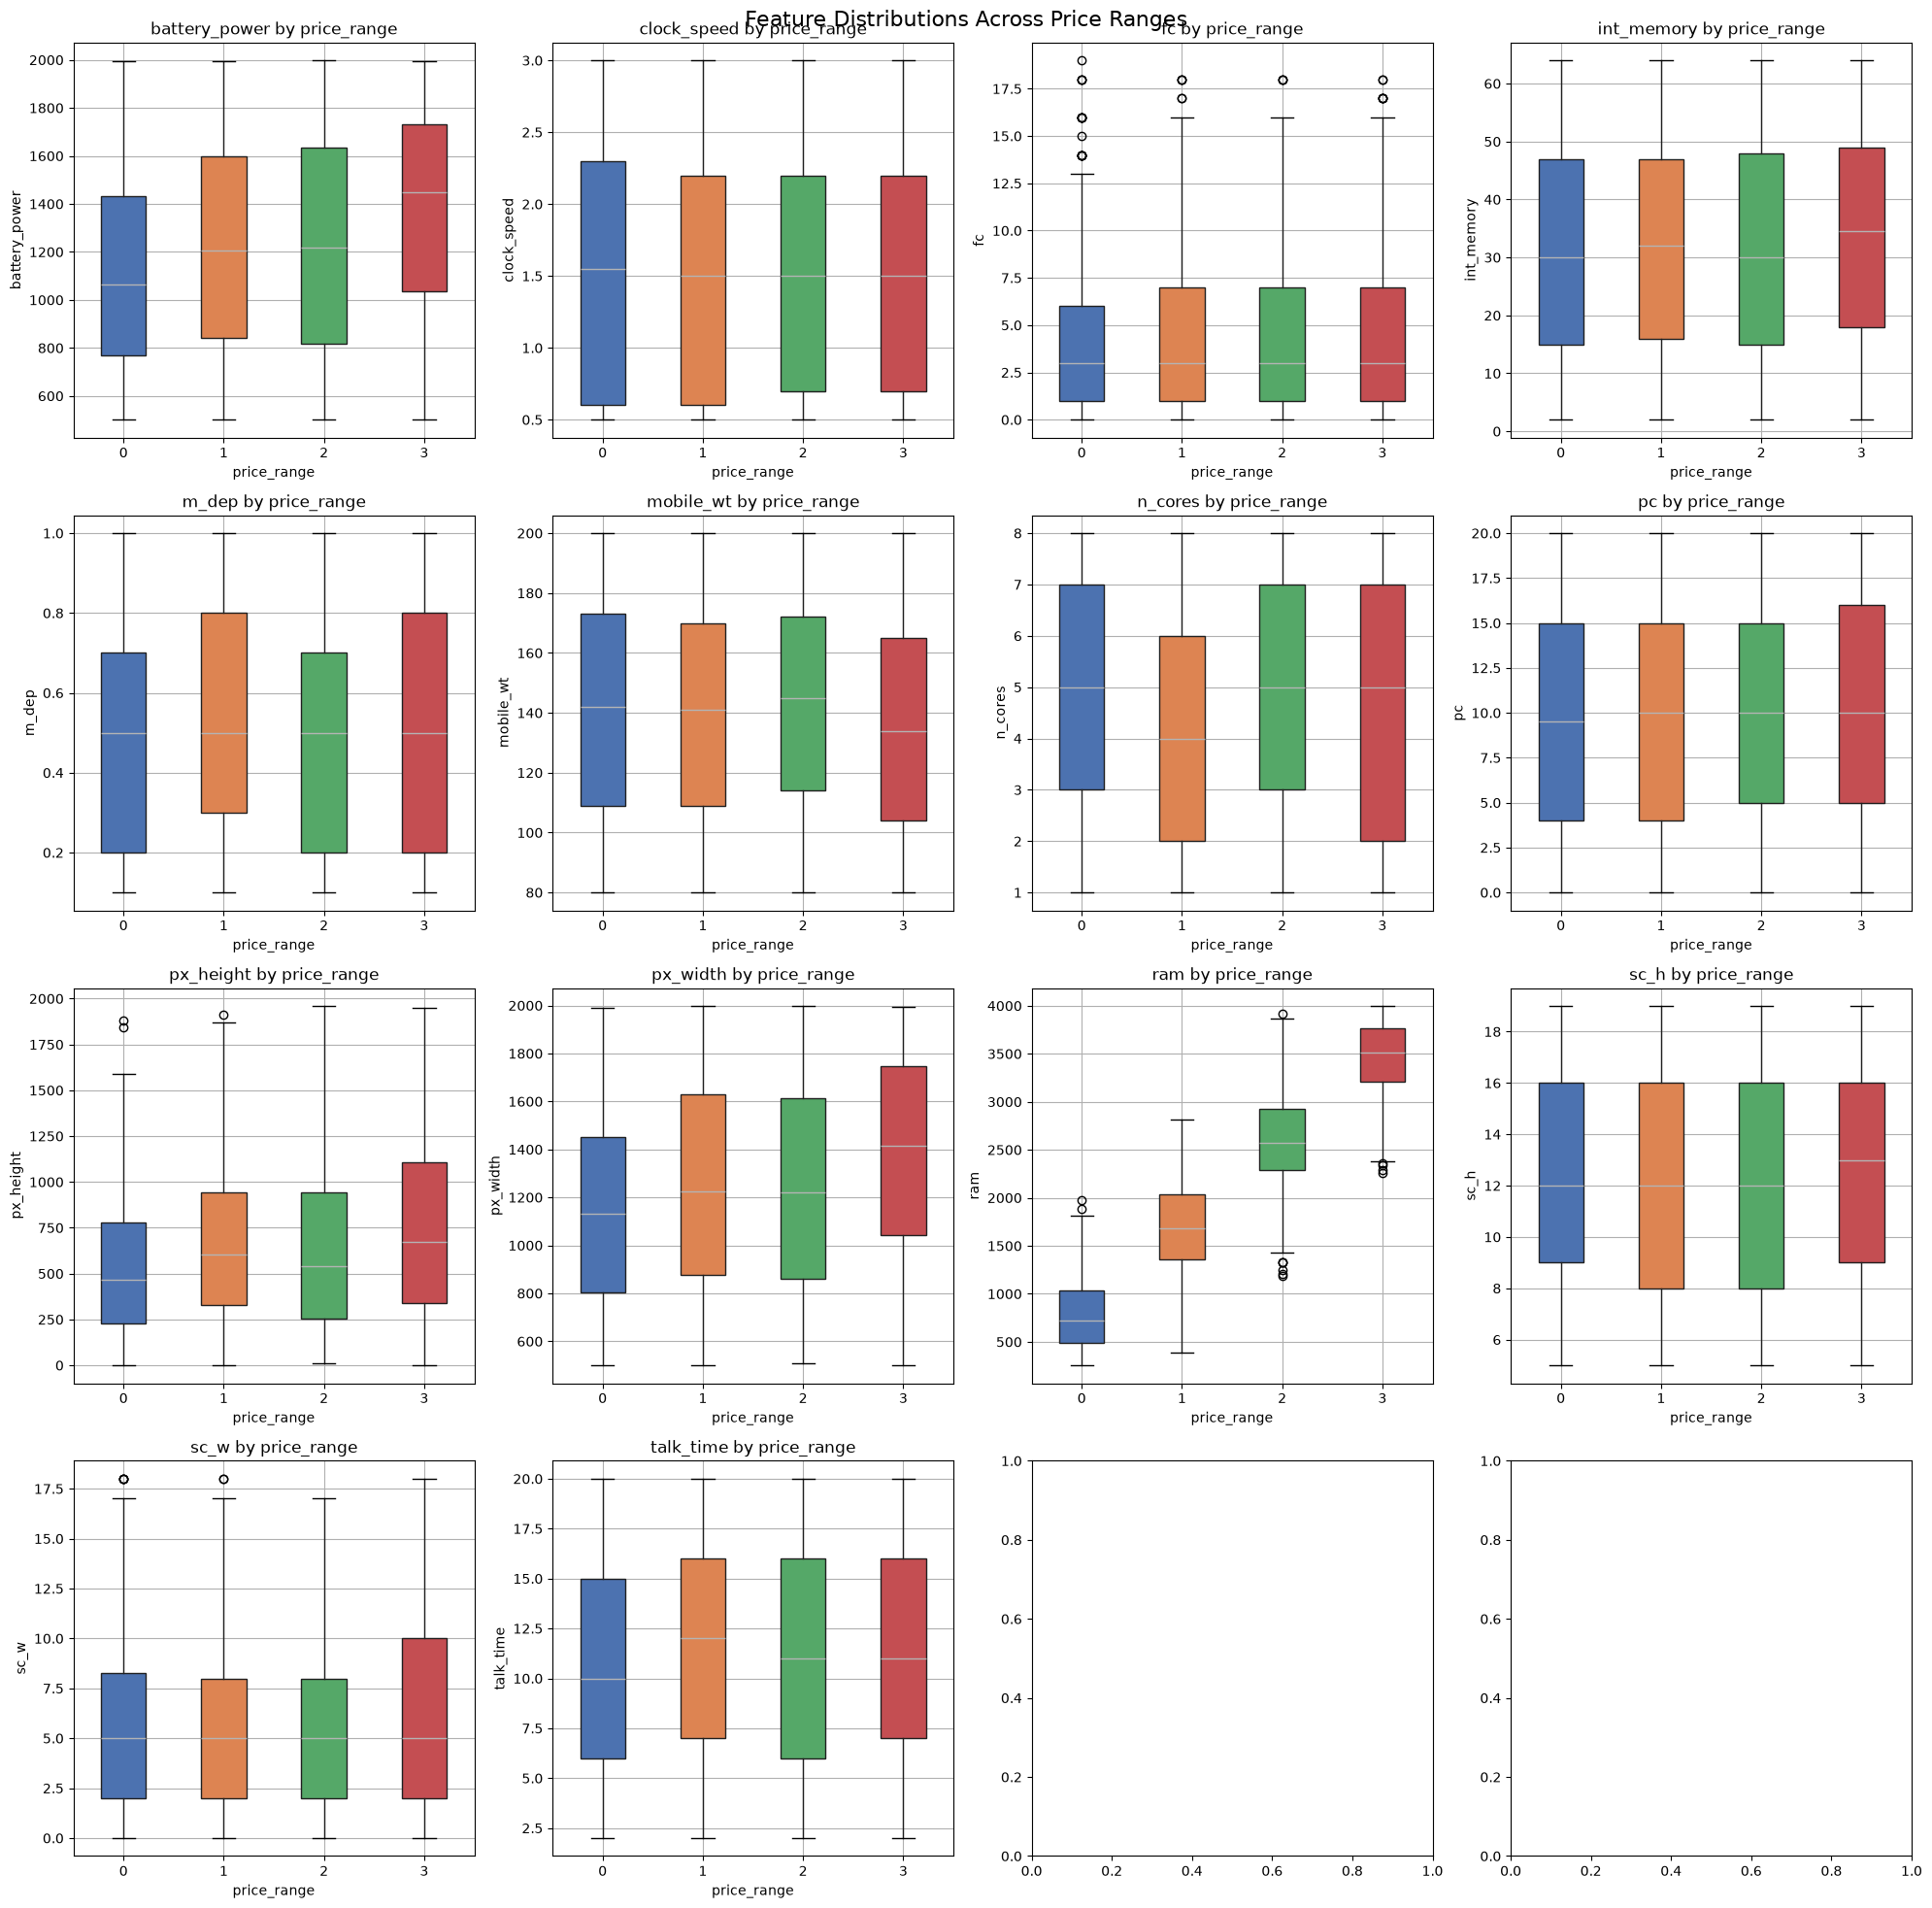

In [174]:
features = df_datas.drop(columns=['price_range']).columns.to_list()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    df_datas.boxplot(column=col, by='price_range', ax=axes[i], patch_artist=True)

    for patch, color in zip(axes[i].patches, colors):
        patch.set_facecolor(color)

    axes[i].set_title(f"{col} by price_range")
    axes[i].set_xlabel('price_range')
    axes[i].set_ylabel(col)

plt.suptitle("Feature Distributions Across Price Ranges", fontsize=16)
plt.tight_layout()
plt.show()

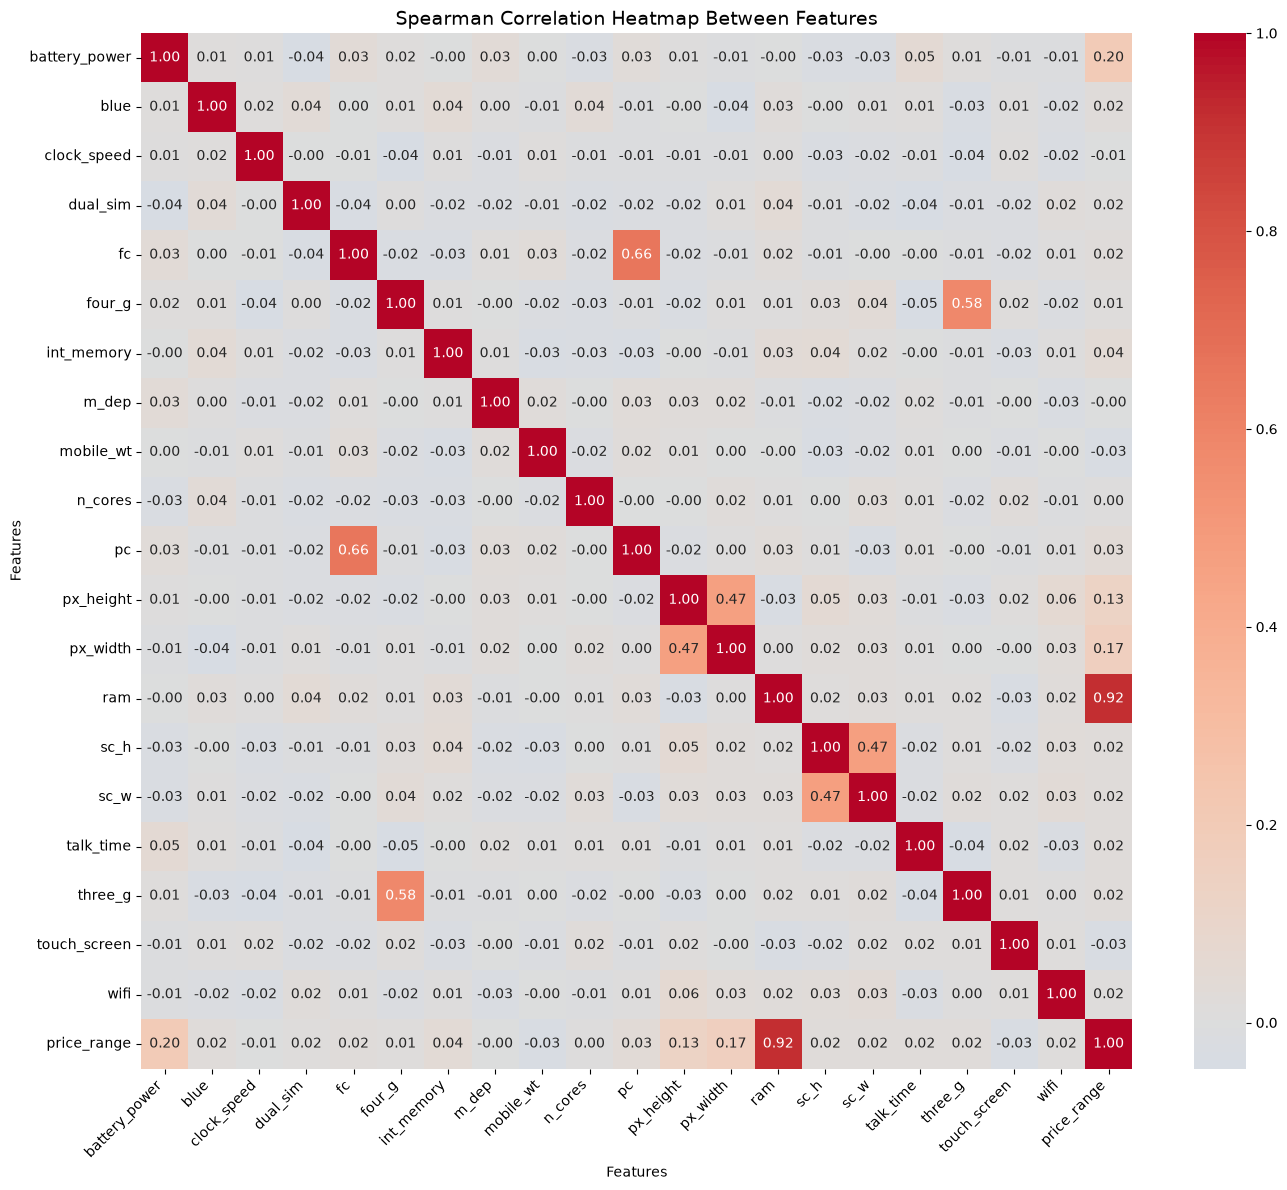

In [ ]:
corr_matrix = df.corr(method='spearman')

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap Between Features", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Features")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Insight Synthesis and Conclusion:

Key determinants of price_range:

- `RAM` is by far the dominant factor:
    - a high correlation with price range (0.92) in the heatmap graph
    - also the highest score in the ANOVA test:
        - ram
    pearson r = 0.9170 (p = 0.0000)
    spearman r = 0.9171 (p = 0.0000)
    conclusion = strong positive correlation
    - boxplots confirm this visually
- We also can see other determinants but with lower values:
    - `battery_power` (0.20), `px_width` (0.166), `px_height` (0.149)
